# <font color='blue'> Principal Component Analysis (PCA) </font>

In the framework of Glen Cowan's *Statistical Data Analysis*, Principal Component Analysis (PCA) is treated as a linear transformation of a set of correlated variables into a new set of **uncorrelated variables**. This is a powerful method for reducing dimensionality and simplifying the analysis of multivariate data by identifying the axes (principal components) along which the data varies the most.



---

## <font color='orange'> 1. The Covariance Matrix </font>
Suppose we have a vector of $n$ random variables $\mathbf{x} = (x_1, ..., x_n)^T$. The first step in PCA is to compute the covariance matrix, $V$, which contains the variances and the correlations between these variables:

$$V_{ij} = \text{cov}[x_i, x_j] = E[(x_i - \mu_i)(x_j - \mu_j)]$$

Where $\mu$ is the vector of mean values. In matrix notation:
$$V = E[(\mathbf{x} - \boldsymbol{\mu})(\mathbf{x} - \boldsymbol{\mu})^T]$$

## <font color='orange'> 2. The Mathematical Goal </font>
We seek a linear transformation $\mathbf{y} = A\mathbf{x}$ such that the resulting covariance matrix of $\mathbf{y}$, denoted $V_y$, is **diagonal**. A diagonal matrix implies that the variables in $\mathbf{y}$ are uncorrelated (i.e., the off-diagonal elements are zero).

According to the rules of error propagation for linear transformations:
$$V_y = A V A^T$$

To diagonalize $V$, we must solve the **eigenvalue problem**:
$$V\mathbf{e}_i = \lambda_i \mathbf{e}_i$$

* $\lambda_i$ are the eigenvalues.
* $\mathbf{e}_i$ are the corresponding eigenvectors.

## <font color='orange'> 3. Constructing the Transformation </font>
If we construct a matrix $P$ where the columns are the normalized eigenvectors ($\mathbf{e}_1, \mathbf{e}_2, ..., \mathbf{e}_n$), then $P$ is an **orthogonal matrix** ($P^{-1} = P^T$).

By transforming the data using $P^T$:
$$\mathbf{y} = P^T \mathbf{x}$$

The new covariance matrix $V_y$ becomes:
$$V_y = P^T V P = D$$

Where $D$ is the diagonal matrix of eigenvalues:
$$D = \begin{bmatrix} \lambda_1 & 0 & \dots & 0 \\ 0 & \lambda_2 & \dots & 0 \\ \vdots & \vdots & \ddots & \vdots \\ 0 & 0 & \dots & \lambda_n \end{bmatrix}$$

## <font color='orange'> 4. Dimensionality Reduction </font>
In practical applications, we often find that many of the eigenvalues $\lambda_i$ are very small. This indicates that the variation of the data along the corresponding principal components (eigenvectors) is minimal.

To reduce dimensionality:
1.  **Sort:** Order the eigenvectors such that their corresponding eigenvalues are in descending order ($\lambda_1 \ge \lambda_2 \ge ... \ge \lambda_n$).
2.  **Truncate:** Keep only the first $k$ eigenvectors that capture the vast majority of the total variance (the sum of the eigenvalues).
3.  **Project:** Project the original $n$-dimensional data onto this $k$-dimensional subspace.



---

## <font color='orange'> Summary of the PCA Procedure </font>

| Step | Action | Mathematical Operation |
| :--- | :--- | :--- |
| **1. Center Data** | Subtract the mean | $\mathbf{x}' = \mathbf{x} - \boldsymbol{\mu}$ |
| **2. Covariance** | Calculate $V$ | $V = \frac{1}{N-1} \sum \mathbf{x}' \mathbf{x}'^T$ |
| **3. Eigen-solve** | Find $\lambda_i$ and $\mathbf{e}_i$ | $\det(V - \lambda I) = 0$ |
| **4. Transform** | Project data | $\mathbf{y} = P^T \mathbf{x}'$ |
| **5. Reduce** | Select top $k$ | Keep $\mathbf{y}_1, ..., \mathbf{y}_k$ |

By performing this rotation, you align your coordinate system with the axes of maximum spread in the data, effectively separating the meaningful signal from the noise (the smaller eigenvalues).

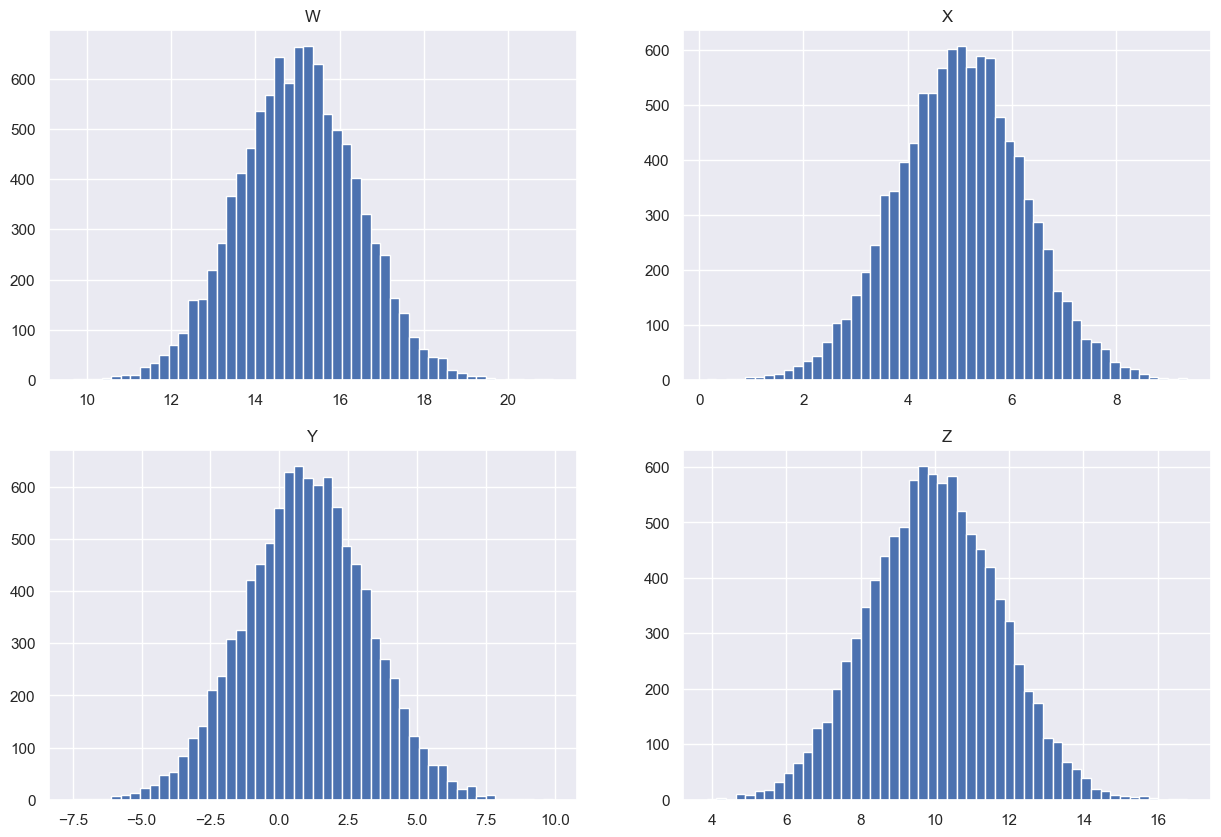

In [7]:
# import the packages we are going to be using
import numpy as np # for getting our distribution
import matplotlib.pyplot as plt # for plotting
import seaborn as sns; sns.set() # For a different plotting theme

# Don't worry so much about what rho is doing here
# Just know if we have a rho of 1 then we will get a perfectly
# upward sloping line, and if we have a rho of -1, we will get 
# a perfectly downward slopping line. A rho of 0 will 
# get us a 'cloud' of points
r12 = r21 = 0.5 # 12 & 21
r13 = r31 = 0.001 # 13 & 31
r14 = r41 = 0.1 # 14 & 41
r23 = r32 = 0.2 # 23 & 32
r24 = r42 = 0.4 # 24 & 42
r34 = r43 = 0.7 # 34 & 43

# Don't worry so much about the following three lines of code for now
# this is just getting the data for us to plot
mean = [15, 5, 1, 10]
cov = [[2, r12, r13, r14], [r21, 1.5, r23, r24], [r31, r32, 5, r34], [r41, r42, r43, 3]]
w, x, y, z = np.random.multivariate_normal(mean, cov, 10000).T

# Adjust the figure size
plt.figure(figsize=(15,10))

# Plot the histograms of X and Y next to each other
plt.subplot(2,2,1)
plt.hist(x = w, bins = 50)
plt.title("W")

plt.subplot(2,2,2)
plt.hist(x = x, bins = 50)
plt.title("X")

plt.subplot(2,2,3)
plt.hist(x = y, bins = 50)
plt.title("Y")

plt.subplot(2,2,4)
plt.hist(x = z, bins = 50)
plt.title("Z")

plt.show()

In [18]:
# let's diagonalise the covariant matrix

import numpy as np

# 1. Define your square matrix A
A = np.array(cov)

# 2. Use numpy.linalg.eig to compute eigenvalues and eigenvectors
# eigenvalues (w) are the diagonal elements of D
# eigenvectors (v) are the columns of P
eigenvalues, P = np.linalg.eig(A)

# 3. Create the diagonal matrix D from the eigenvalues
D = np.diag(eigenvalues)

# 4. Calculate P inverse
P_inv = np.linalg.inv(P)

# 5. Verify the diagonalization (A = PDP^-1)
# The '@' operator performs matrix multiplication in NumPy
A_reconstructed = P @ D @ P_inv

print("Original Matrix A:\n", A)
print("\nDiagonal Matrix D:\n", D)
print("\nEigenvector Matrix P:\n", P)
print("\nVerification (PDP^-1):\n", np.round(A_reconstructed, 5))

Original Matrix A:
 [[2.0e+00 5.0e-01 1.0e-03 1.0e-01]
 [5.0e-01 1.5e+00 2.0e-01 4.0e-01]
 [1.0e-03 2.0e-01 5.0e+00 7.0e-01]
 [1.0e-01 4.0e-01 7.0e-01 3.0e+00]]

Diagonal Matrix D:
 [[1.14349687 0.         0.         0.        ]
 [0.         2.20049732 0.         0.        ]
 [0.         0.         2.90753011 0.        ]
 [0.         0.         0.         5.24847569]]

Eigenvector Matrix P:
 [[-0.48473133  0.83613946 -0.25566995 -0.02322105]
 [ 0.86099899  0.40756178 -0.29162535 -0.08676865]
 [-0.01673876  0.06109634  0.31747727 -0.94614758]
 [-0.15308853 -0.36198265 -0.86532983 -0.31102532]]

Verification (PDP^-1):
 [[2.0e+00 5.0e-01 1.0e-03 1.0e-01]
 [5.0e-01 1.5e+00 2.0e-01 4.0e-01]
 [1.0e-03 2.0e-01 5.0e+00 7.0e-01]
 [1.0e-01 4.0e-01 7.0e-01 3.0e+00]]


## 1. The Sorting Rule

In standard PCA, the principal components are ordered by their eigenvalues in **descending order**, since larger eigenvalues correspond to directions of greater variance.

For your data, the eigenvalues should be ordered as:

$$\lambda_1 = 5.248, \quad \lambda_2 = 2.907, \quad \lambda_3 = 2.200, \quad \lambda_4 = 1.143$$

---

## 2. Calculating the Explained Variance

To determine how much information each principal component retains, compute the **explained variance ratio**.

The total variance is the sum of all eigenvalues:

$$\text{Total Variance} = \sum_{i} \sigma_{i}^{2} = \sum_{i=1}^{4} \lambda_i = 5.248 + 2.907 + 2.200 + 1.143 = 11.498$$

The explained variance ratio for the $i^{\text{th}}$ principal component is:

$$\text{Explained Variance Ratio}_i = \frac{\lambda_i}{\text{Total Variance}}$$



| Component | Eigenvalue ($\lambda$) | Explained Variance |
| :--- | :--- | :--- |
| PC1 | 5.248 | $\approx 46\%$ |
| PC2 | 2.907 | $\approx 25\%$ |
| PC3 | 2.200 | $\approx 19\%$ |
| PC4 | 1.143 | $\approx 10\%$ |
| **Total** | **11.498** | **100%** |

---

## 3. Dimensionality Reduction

The explained variance ratios allow you to decide how many principal components to retain.



* **Retaining approximately 90% of the information**
    Keeping **PC1**, **PC2**, and **PC3** preserves approximately:
    $$46\% + 25\% + 19\% \approx 90\%$$
    of the total variance. This reduces the dataset from **4 dimensions to 3 dimensions**.

* **Retaining only the dominant patterns**
    Keeping only **PC1** and **PC2** preserves approximately:
    $$46\% + 25\% \approx 71\%$$
    of the total variance, giving you a simplified **2-dimensional representation** of the data.


### Thus, we can drop `w` altogether.

## Start with transforming the variables using the eigenvectors:  
$$\mathbf{X}^{'} = \mathbf{P}^{T}\mathbf{X}$$  

where **P** is the reduced eigenvector with `w` row truncated

P_updated is :
[[ 0.83613946 -0.25566995 -0.02322105]
 [ 0.40756178 -0.29162535 -0.08676865]
 [ 0.06109634  0.31747727 -0.94614758]
 [-0.36198265 -0.86532983 -0.31102532]]
Original P was: 
[[-0.48473133  0.83613946 -0.25566995 -0.02322105]
 [ 0.86099899  0.40756178 -0.29162535 -0.08676865]
 [-0.01673876  0.06109634  0.31747727 -0.94614758]
 [-0.15308853 -0.36198265 -0.86532983 -0.31102532]]


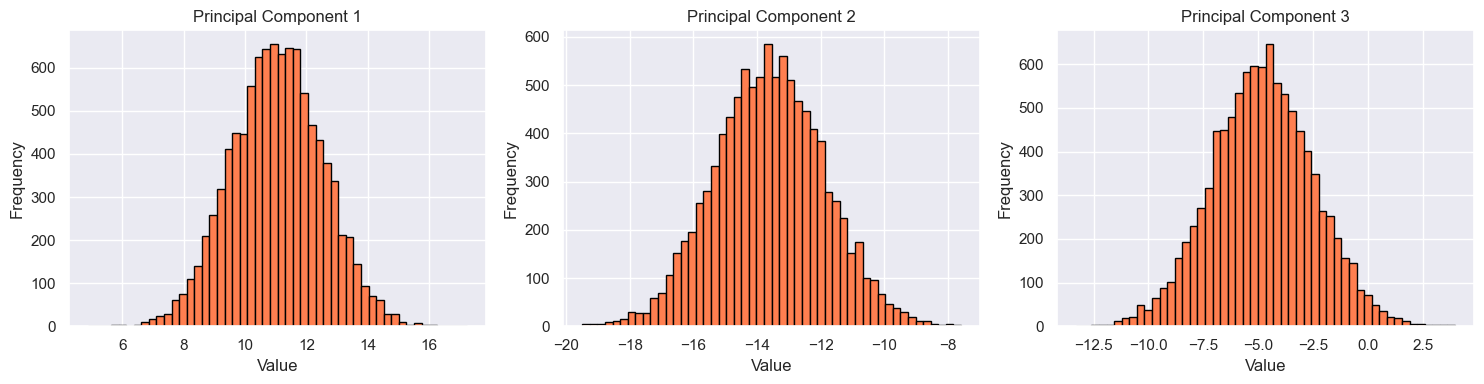

In [19]:
P_updated = np.delete(P, 0, axis=1)
print("P_updated is :")
print(P_updated)

print("Original P was: ")
print(P)

# 1. Stack all four variables
X = np.column_stack((w, x, y, z)) # Shape (10000, 4)

# 2. Get your reduced eigenvector matrix (P_k)
# Assume you calculated P (4x4) and decided to keep only columns 1, 2, and 3 
# (dropping the one corresponding to the smallest eigenvalue, or whichever you choose)
P_reduced = P[:, [1, 2, 3]] # This is a (4, 3) matrix

# 3. Project the data
X_reduced = X @ P_reduced # Result is (10000, 3)


import matplotlib.pyplot as plt

# X_reduced is your (N, k) matrix
num_components = X_reduced.shape[1]

# Create a layout that fits your number of components
# If you have 3 components, a 1x3 or 3x1 grid works well
fig, axes = plt.subplots(1, num_components, figsize=(15, 4))

# Handle the case where num_components is 1 (axes is not a list)
if num_components == 1:
    axes = [axes]

for i in range(num_components):
    axes[i].hist(X_reduced[:, i], bins=50, color='coral', edgecolor='black')
    axes[i].set_title(f"Principal Component {i+1}")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

Explained variance by PC1: 72.96%
Explained variance by PC2: 22.85%


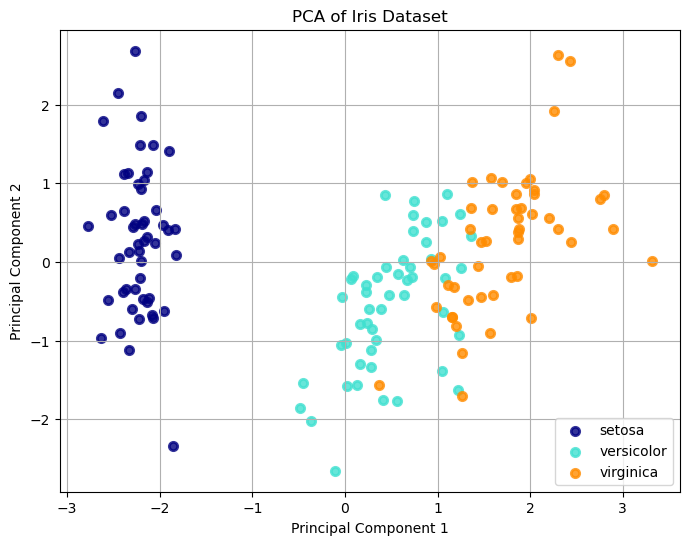

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Load the Dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

# 2. Standardization
# Cowan's PCA assumes variables are comparable; we scale to unit variance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Apply PCA
# We reduce from 4 dimensions to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. Analyze Explained Variance
# This shows how much "information" (variance) each PC captures
explained_variance = pca.explained_variance_ratio_
print(f"Explained variance by PC1: {explained_variance[0]:.2%}")
print(f"Explained variance by PC2: {explained_variance[1]:.2%}")

# 5. Visualization
plt.figure(figsize=(8, 6))
colors = ['navy', 'turquoise', 'darkorange']
for color, i, target_name in zip(colors, [0, 1, 2], iris.target_names):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], 
                color=color, alpha=.8, lw=2, label=target_name)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Iris Dataset')
plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.grid(True)
plt.show()